# Post Features and Discourse Types Multinomial Logistic Regression

## Objective
This notebook analyzes the relationship between post characteristics and discourse types (comment clusters) using multinomial logistic regression.

**Features (Predictors):** Post characteristics
- Post length (character count)
- Word count
- Unique words ratio
- Uppercase percentage
- Has hashtags (binary)
- Has questions (binary)
- Has URLs (binary)

**Target Variable:** Discourse Types (Comment clusters)
- On-topic Feedbacks
- On-topic Criticism  
- On-topic Praise
- Off-topic Complaints
- Content Sharing
- Information Seeking (baseline)

**Statistical Method:** Multinomial Logistic Regression
**Reference Categories:** 
- Post features: 'Low' level (excluded)
- Discourse type: 'Information Seeking' (baseline)

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder
import re
import warnings
warnings.filterwarnings('ignore')

print("📝 POST FEATURES AND DISCOURSE TYPES ANALYSIS")
print("=" * 46)
print("📊 Libraries loaded successfully!")

📝 POST FEATURES AND DISCOURSE TYPES ANALYSIS
📊 Libraries loaded successfully!


In [2]:
# Load Data
print("📂 LOADING DATA")
print("=" * 15)

# Load the dataset with K-means clusters
data_path = r"C:\Users\20245179\OneDrive - TU Eindhoven\Research Paper\Analysis_pipeline\CLustered_Kmeans_with_HA_features.csv"
df = pd.read_csv(data_path)

print(f"✅ Data loaded successfully!")
print(f"📊 Dataset shape: {df.shape}")
print(f"🎯 Target variable: Cluster_KMeans (Discourse Types)")

# Define discourse type mapping
discourse_type_map = {
    0: 'On-topic Feedbacks',
    1: 'On-topic Criticism', 
    2: 'On-topic Praise',
    3: 'Off-topic Complaints',
    4: 'Content Sharing',
    5: 'Information Seeking'
}

# Check discourse type distribution
cluster_dist = df['Cluster_KMeans'].value_counts().sort_index()
print(f"\n🎯 Discourse Type Distribution:")
for cluster, count in cluster_dist.items():
    percentage = (count / len(df)) * 100
    discourse_type = discourse_type_map[cluster]
    print(f"   {cluster} - {discourse_type}: {count:,} samples ({percentage:.1f}%)")

print(f"\n📊 Total samples: {len(df):,}")

📂 LOADING DATA
✅ Data loaded successfully!
📊 Dataset shape: (3197, 37)
🎯 Target variable: Cluster_KMeans (Discourse Types)

🎯 Discourse Type Distribution:
   0 - On-topic Feedbacks: 431 samples (13.5%)
   1 - On-topic Criticism: 928 samples (29.0%)
   2 - On-topic Praise: 171 samples (5.3%)
   3 - Off-topic Complaints: 541 samples (16.9%)
   4 - Content Sharing: 398 samples (12.4%)
   5 - Information Seeking: 728 samples (22.8%)

📊 Total samples: 3,197


In [3]:
# Examine Dataset Structure for POST Content
print("🔍 EXAMINING DATASET FOR POST CONTENT")
print("=" * 36)

print("📊 Available columns in dataset:")
print("-" * 32)

for i, col in enumerate(df.columns, 1):
    print(f"   {i:2d}. {col}")

print(f"\n📋 Dataset shape: {df.shape}")

# Look for post-related columns
post_columns = [col for col in df.columns if 'post' in col.lower()]
print(f"\n📝 Columns containing 'post': {post_columns}")

# Check first few rows to understand data structure
print(f"\n🔍 Sample data (first 3 rows, key columns):")
print("-" * 45)

# Show Comment vs potential post columns
key_cols = ['Comment'] + [col for col in df.columns if 'post' in col.lower() or 'content' in col.lower() or 'text' in col.lower()]
if len(key_cols) > 1:
    sample_data = df[key_cols].head(3)
    for col in sample_data.columns:
        print(f"\n{col}:")
        for idx, value in sample_data[col].items():
            preview = str(value)[:100] + "..." if len(str(value)) > 100 else str(value)
            print(f"   Row {idx}: {preview}")
else:
    print("   Only 'Comment' column found - checking if this contains post content...")
    
# Check if there are any identifier columns that might help distinguish posts from comments
id_columns = [col for col in df.columns if any(keyword in col.lower() for keyword in ['id', 'post', 'thread', 'parent'])]
print(f"\n🔗 Identifier columns: {id_columns}")

if id_columns:
    print(f"\nSample identifier data:")
    for col in id_columns[:3]:  # Show first 3 ID columns
        unique_count = df[col].nunique()
        print(f"   {col}: {unique_count:,} unique values out of {len(df):,} rows")
        if unique_count < 20:  # Show values if small number
            print(f"      Values: {sorted(df[col].unique())}")
        else:
            print(f"      Sample values: {sorted(df[col].unique())[:5]}...")

🔍 EXAMINING DATASET FOR POST CONTENT
📊 Available columns in dataset:
--------------------------------
    1. Unnamed: 0
    2. Post
    3. Comment
    4. Comments_time
    5. Sentiment
    6. final_label_three_models_final
    7. GRO_NLP_prob_Appreciation
    8. GRO_NLP_prob_Criticism
    9. GRO_NLP_prob_Inquiry
   10. GRO_NLP_prob_Statement
   11. roberta_prob_Appreciation
   12. roberta_prob_Criticism
   13. roberta_prob_Inquiry
   14. roberta_prob_Statement
   15. debertaV3_prob_Appreciation
   16. debertaV3_prob_Criticism
   17. debertaV3_prob_Inquiry
   18. debertaV3_prob_Statement
   19. Similarity
   20. Similarity_Category
   21. avg_prob_Appreciation
   22. avg_prob_Criticism
   23. avg_prob_Inquiry
   24. avg_prob_Statement
   25. avg_prob_Forward
   26. Cluster_KMeans
   27. PC1
   28. PC2
   29. Author
   30. Number of houses(DAEB)
   31. Number of houses(niet_DAEB)
   32. Total Housing
   33. Operation expense/unit
   34. Tenants Left
   35. Maintainance cost/unit
   36. A

In [7]:
df

,Unnamed: 0,Post,Comment,Comments_time,Sentiment,final_label_three_models_final,GRO_NLP_prob_Appreciation,GRO_NLP_prob_Criticism,GRO_NLP_prob_Inquiry,GRO_NLP_prob_Statement,...,PC2,Author,Number of houses(DAEB),Number of houses(niet_DAEB),Total Housing,Operation expense/unit,Tenants Left,Maintainance cost/unit,Affordability(Rent/month),Tenants Repair Request
0,0,De zonnepanelen op het dak van ons kantoor doe...,hoeveel KWh hebben de zonnepanelen op de wezen...,2019-04-02 22:14:59,-1,Inquiry,0.010445,0.011370,0.968024,0.010161,...,0.732400,WormerWonen,2233.0,41.0,2274.0,1002.0,8.2,2124.0,548.0,7.9
1,1,IN ACTI-UM | Onze vakmannen vervangen bij iede...,Dan kom ik langs voor sleutels en krijg er gra...,2018-12-21 15:37:26,0,Criticism,0.027336,0.024728,0.752228,0.195707,...,0.084632,Actium,15227.0,27.0,15254.0,850.0,7.9,2782.0,535.0,7.8
2,2,IN ACTI-UM | Onze vakmannen vervangen bij iede...,"Mmmm, iets nieuws? Wij hebben in maart geen wi...",2018-12-21 10:57:48,-1,Statement,0.013757,0.042974,0.139054,0.804214,...,-0.716585,Actium,15227.0,27.0,15254.0,850.0,7.9,2782.0,535.0,7.8
3,3,Een hoog energieverbruik is slecht voor het mi...,Het zou beter zijn als Samenwerking een aantal...,2018-08-01 15:22:31,-1,Statement,0.011030,0.014280,0.021973,0.952717,...,-0.921441,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,Een hoog energieverbruik is slecht voor het mi...,Leuk als je in een woning woont met warmtepomp...,2018-07-31 11:51:36,0,Criticism,0.047389,0.200883,0.034253,0.717475,...,0.152901,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3192,3192,Vorige week zijn de laatste huizen van 't Getf...,Kijk onze wijk <PERSON> <PERSON> Paulo Mariaa ...,2019-07-30 10:57:55,0,Statement,0.040425,0.046785,0.503709,0.409080,...,0.173767,De Woonplaats,15287.0,668.0,15955.0,857.0,7.4,2606.0,585.0,7.7
3193,3193,Op de 1e verdieping van het oude schoolgebouw ...,Is er genoeg ventilatie en / of kunnen ramen g...,2020-10-22 12:40:07,0,Inquiry,0.010553,0.010469,0.968225,0.010752,...,0.818739,Woongoed Zeist,16105.0,200.0,16305.0,800.0,8.7,3000.0,606.0,7.5
3194,3194,Op de 1e verdieping van het oude schoolgebouw ...,<PERSON> kan je dus straks gebruik van maken. ...,2020-10-21 15:54:40,0,Forward,0.026950,0.707743,0.056919,0.208388,...,-0.818682,Woongoed Zeist,16105.0,200.0,16305.0,800.0,8.7,3000.0,606.0,7.5
3195,3195,Op de 1e verdieping van het oude schoolgebouw ...,Komen er nog meer werkplekken bij? Of blijft h...,2020-10-19 10:14:18,-1,Inquiry,0.011488,0.011212,0.966778,0.010522,...,0.513431,Woongoed Zeist,16105.0,200.0,16305.0,800.0,8.7,3000.0,606.0,7.5


In [4]:
# Create Post Features (CORRECTED - Using POST content, not comments)
print("📝 POST FEATURE ENGINEERING (CORRECTED)")
print("=" * 38)

# Create a copy for feature engineering
df_model = df.copy()

# IMPORTANT FIX: Use 'Post' column for post features, not 'Comment' column
df_model['Post'] = df_model['Post'].astype(str)

print("🔧 Creating post characteristics features from POST content...")
print("⚠️  CORRECTION: Now using 'Post' column (actual posts) instead of 'Comment' column")

# 1. Post length (word count) - FROM THE ACTUAL POST
df_model['post_length'] = df_model['Post'].apply(lambda x: len(str(x).split()))

# 2. Length categories - BASED ON POST LENGTH
bins = [0, 50, 150, 300, np.inf]
labels = ["tweet (<50)", "short (50-150)", "abstract (150-300)", "long (>300)"]
df_model["length_category"] = pd.cut(df_model["post_length"], bins=bins, labels=labels,
                                    right=True, include_lowest=True)

# 3. Number of unique words - FROM THE ACTUAL POST
df_model['unique_words'] = df_model['Post'].apply(lambda x: len(set(str(x).split())))

# 4. Unique words percentage - BASED ON POST CONTENT
df_model['unique_words_ratio'] = ((df_model['unique_words'] / df_model['post_length']) * 100).round(2)
# Handle division by zero
df_model['unique_words_ratio'] = df_model['unique_words_ratio'].fillna(0)

# 5. Question present (binary) - QUESTIONS IN THE POST
df_model["has_questions"] = df_model["Post"].str.contains(r"\?", regex=True).astype(int)

# 6. URL present (binary) - URLS IN THE POST
df_model["has_urls"] = df_model["Post"].str.contains(r"http\S+", regex=True).astype(int)

# Define post features list
# Categorical features to categorize
categorical_post_features = [
    'length_category',  # Will be used as categorical directly
    'unique_words_ratio'  # Will be categorized into Low/Medium/High
]

# Binary features
binary_post_features = [
    'has_questions',
    'has_urls'
]

# All post features for analysis (only the 4 final features)
post_features = ['unique_words_ratio', 'length_category'] + binary_post_features

print(f"✅ Created {len(post_features)} POST features for analysis:")
print("\n📊 Categorical Features (from POST content):")
for i, feature in enumerate(categorical_post_features, 1):
    if feature == 'length_category':
        print(f"   {i}. {feature} (used as categorical)")
    else:
        print(f"   {i}. {feature} (will be categorized into Low/Medium/High)")
    
print("\n🔢 Binary Features (from POST content):")
for i, feature in enumerate(binary_post_features, 1):
    print(f"   {i}. {feature}")

print(f"\n📝 Note: post_length and unique_words calculated from POST column, not Comment column")

# Show basic statistics for POST features
print(f"\n📈 POST Features Statistics (4 features for modeling):")
print("-" * 65)
post_stats = df_model[post_features].describe()
print(post_stats.round(3))

# Show length category distribution for POSTS
print(f"\n📏 POST Length Category Distribution:")
length_dist = df_model['length_category'].value_counts()
for category, count in length_dist.items():
    percentage = (count / len(df_model)) * 100
    print(f"   {category}: {count:,} ({percentage:.1f}%)")

# Show unique words ratio distribution for POSTS
print(f"\n📊 POST Unique Words Ratio Statistics:")
print(f"   Mean: {df_model['unique_words_ratio'].mean():.2f}%")
print(f"   Median: {df_model['unique_words_ratio'].median():.2f}%")
print(f"   Min: {df_model['unique_words_ratio'].min():.2f}%")
print(f"   Max: {df_model['unique_words_ratio'].max():.2f}%")

# Compare POST vs COMMENT statistics to show the difference
print(f"\n🔄 COMPARISON: POST vs COMMENT characteristics:")
print("-" * 48)

# Calculate comment characteristics for comparison
comment_length = df_model['Comment'].apply(lambda x: len(str(x).split()))
post_length = df_model['post_length']

print(f"   Average POST length: {post_length.mean():.1f} words")
print(f"   Average COMMENT length: {comment_length.mean():.1f} words")
print(f"   ")
print(f"   POST questions: {df_model['has_questions'].sum()} posts ({df_model['has_questions'].mean()*100:.1f}%)")
comment_questions = df_model['Comment'].str.contains(r"\?", regex=True).astype(int)
print(f"   COMMENT questions: {comment_questions.sum()} comments ({comment_questions.mean()*100:.1f}%)")

print(f"   ")
print(f"   POST URLs: {df_model['has_urls'].sum()} posts ({df_model['has_urls'].mean()*100:.1f}%)")
comment_urls = df_model['Comment'].str.contains(r"http\S+", regex=True).astype(int)
print(f"   COMMENT URLs: {comment_urls.sum()} comments ({comment_urls.mean()*100:.1f}%)")

# Check for missing values
missing_values = df_model[post_features].isnull().sum()
if missing_values.sum() > 0:
    print(f"\n⚠️  Missing values found:")
    print(missing_values[missing_values > 0])
else:
    print(f"\n✅ No missing values in POST features")

print(f"\n🎯 Now analyzing POST characteristics that lead to different discourse types in comments!")

📝 POST FEATURE ENGINEERING (CORRECTED)
🔧 Creating post characteristics features from POST content...
⚠️  CORRECTION: Now using 'Post' column (actual posts) instead of 'Comment' column
✅ Created 4 POST features for analysis:

📊 Categorical Features (from POST content):
   1. length_category (used as categorical)
   2. unique_words_ratio (will be categorized into Low/Medium/High)

🔢 Binary Features (from POST content):
   1. has_questions
   2. has_urls

📝 Note: post_length and unique_words calculated from POST column, not Comment column

📈 POST Features Statistics (4 features for modeling):
-----------------------------------------------------------------
       unique_words_ratio  has_questions  has_urls
count            3197.000       3197.000  3197.000
mean               82.308          0.481     0.374
std                 8.476          0.500     0.484
min                54.070          0.000     0.000
25%                75.860          0.000     0.000
50%                83.130      

In [8]:
df_model

,Unnamed: 0,Post,Comment,Comments_time,Sentiment,final_label_three_models_final,GRO_NLP_prob_Appreciation,GRO_NLP_prob_Criticism,GRO_NLP_prob_Inquiry,GRO_NLP_prob_Statement,...,Affordability(Rent/month),Tenants Repair Request,post_length,length_category,unique_words,unique_words_ratio,has_questions,has_urls,unique_words_cat,unique_words_ratio_Level
0,0,De zonnepanelen op het dak van ons kantoor doe...,hoeveel KWh hebben de zonnepanelen op de wezen...,2019-04-02 22:14:59,-1,Inquiry,0.010445,0.011370,0.968024,0.010161,...,548.0,7.9,65,short (50-150),49,75.38,0,0,Low,Low
1,1,IN ACTI-UM | Onze vakmannen vervangen bij iede...,Dan kom ik langs voor sleutels en krijg er gra...,2018-12-21 15:37:26,0,Criticism,0.027336,0.024728,0.752228,0.195707,...,535.0,7.8,61,short (50-150),47,77.05,0,0,Low,Low
2,2,IN ACTI-UM | Onze vakmannen vervangen bij iede...,"Mmmm, iets nieuws? Wij hebben in maart geen wi...",2018-12-21 10:57:48,-1,Statement,0.013757,0.042974,0.139054,0.804214,...,535.0,7.8,61,short (50-150),47,77.05,0,0,Low,Low
3,3,Een hoog energieverbruik is slecht voor het mi...,Het zou beter zijn als Samenwerking een aantal...,2018-08-01 15:22:31,-1,Statement,0.011030,0.014280,0.021973,0.952717,...,NaN,NaN,51,short (50-150),48,94.12,1,1,High,High
4,4,Een hoog energieverbruik is slecht voor het mi...,Leuk als je in een woning woont met warmtepomp...,2018-07-31 11:51:36,0,Criticism,0.047389,0.200883,0.034253,0.717475,...,NaN,NaN,51,short (50-150),48,94.12,1,1,High,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3192,3192,Vorige week zijn de laatste huizen van 't Getf...,Kijk onze wijk <PERSON> <PERSON> Paulo Mariaa ...,2019-07-30 10:57:55,0,Statement,0.040425,0.046785,0.503709,0.409080,...,585.0,7.7,46,tweet (<50),37,80.43,0,0,Medium,Medium
3193,3193,Op de 1e verdieping van het oude schoolgebouw ...,Is er genoeg ventilatie en / of kunnen ramen g...,2020-10-22 12:40:07,0,Inquiry,0.010553,0.010469,0.968225,0.010752,...,606.0,7.5,62,short (50-150),53,85.48,0,0,Medium,Medium
3194,3194,Op de 1e verdieping van het oude schoolgebouw ...,<PERSON> kan je dus straks gebruik van maken. ...,2020-10-21 15:54:40,0,Forward,0.026950,0.707743,0.056919,0.208388,...,606.0,7.5,62,short (50-150),53,85.48,0,0,Medium,Medium
3195,3195,Op de 1e verdieping van het oude schoolgebouw ...,Komen er nog meer werkplekken bij? Of blijft h...,2020-10-19 10:14:18,-1,Inquiry,0.011488,0.011212,0.966778,0.010522,...,606.0,7.5,62,short (50-150),53,85.48,0,0,Medium,Medium


In [13]:
df_posts = df_model.drop_duplicates(subset='Post').copy()

print(f"Total unique posts: {len(df_posts)}")

length_counts = df_posts['length_category'].value_counts().sort_index()
length_pct = (length_counts / len(df_posts) * 100).round(1)
print("\nLength Category:")
print(pd.DataFrame({'Count': length_counts, 'Percentage (%)': length_pct}))

uwr_counts = df_posts['unique_words_cat'].value_counts().sort_index()
uwr_pct = (uwr_counts / len(df_posts) * 100).round(1)
print("\nUnique Words Ratio:")
print(pd.DataFrame({'Count': uwr_counts, 'Percentage (%)': uwr_pct}))

q_counts = df_posts['has_questions'].value_counts().rename({0: 'No Question', 1: 'Has Question'})
q_pct = (q_counts / len(df_posts) * 100).round(1)
print("\nQuestion Presence:")
print(pd.DataFrame({'Count': q_counts, 'Percentage (%)': q_pct}))

url_counts = df_posts['has_urls'].value_counts().rename({0: 'No URL', 1: 'Has URL'})
url_pct = (url_counts / len(df_posts) * 100).round(1)
print("\nURL Presence:")
print(pd.DataFrame({'Count': url_counts, 'Percentage (%)': url_pct}))

Total unique posts: 792

Length Category:
                    Count  Percentage (%)
length_category                          
tweet (<50)           253            31.9
short (50-150)        474            59.8
abstract (150-300)     63             8.0
long (>300)             2             0.3

Unique Words Ratio:
                  Count  Percentage (%)
unique_words_cat                       
Low                 241            30.4
Medium              271            34.2
High                280            35.4

Question Presence:
               Count  Percentage (%)
has_questions                       
No Question      436            55.1
Has Question     356            44.9

URL Presence:
          Count  Percentage (%)
has_urls                       
No URL      480            60.6
Has URL     312            39.4


In [12]:
length_counts

length_category
tweet (<50)           253
short (50-150)        474
abstract (150-300)     63
long (>300)             2
Name: count, dtype: int64

In [6]:
# Categorize Continuous Post Features
print("🔧 FEATURE CATEGORIZATION")
print("=" * 25)

print("📊 Processing categorical and continuous features:")
print("-" * 50)

# Features to categorize using tertiles (only unique_words_ratio)
continuous_features = ['unique_words_ratio']

# Categorical feature to use directly (length_category)
direct_categorical_features = ['length_category']

# Binary features (keep as is) 
binary_features = binary_post_features  # Use the list defined above

# Categorize continuous features into Low/Medium/High
for feature in continuous_features:
    # Calculate tertiles
    q33 = df_model[feature].quantile(0.33)
    q67 = df_model[feature].quantile(0.67)
    
    # Create categorical levels
    level_col = f"{feature}_Level"
    df_model[level_col] = pd.cut(
        df_model[feature],
        bins=[-np.inf, q33, q67, np.inf],
        labels=['Low', 'Medium', 'High']
    )
    
    print(f"✅ {feature} categorized:")
    print(f"   Low: ≤ {q33:.3f} | Medium: {q33:.3f} - {q67:.3f} | High: > {q67:.3f}")
    
    # Show distribution
    level_dist = df_model[level_col].value_counts()
    print(f"   Distribution: Low: {level_dist['Low']}, Medium: {level_dist['Medium']}, High: {level_dist['High']}")
    print()

# Create final list of post feature columns for modeling
post_feature_columns = []

# Add categorical versions of continuous features
for feature in continuous_features:
    post_feature_columns.append(f"{feature}_Level")

# Add direct categorical features
for feature in direct_categorical_features:
    post_feature_columns.append(feature)

# Add binary features as is
for feature in binary_features:
    post_feature_columns.append(feature)

print(f"📊 Final post feature columns for modeling ({len(post_feature_columns)}):")
for i, feature in enumerate(post_feature_columns, 1):
    print(f"   {i:2d}. {feature}")
    
print(f"\n🎯 These {len(post_feature_columns)} features will be used to predict discourse types")
print(f"📝 Features include: post length categories, unique words percentage, and interaction patterns")

🔧 FEATURE CATEGORIZATION
📊 Processing categorical and continuous features:
--------------------------------------------------
✅ unique_words_ratio categorized:
   Low: ≤ 78.460 | Medium: 78.460 - 86.440 | High: > 86.440
   Distribution: Low: 1057, Medium: 1101, High: 1039

📊 Final post feature columns for modeling (4):
    1. unique_words_ratio_Level
    2. length_category
    3. has_questions
    4. has_urls

🎯 These 4 features will be used to predict discourse types
📝 Features include: post length categories, unique words percentage, and interaction patterns


In [ ]:
# Prepare Data for Modeling
print("🔄 DATA PREPARATION FOR MODELING")
print("=" * 33)

# Select features and target
model_data = df_model[post_feature_columns + ['Cluster_KMeans']].copy()

print(f"📊 Model data shape: {model_data.shape}")
print(f"🎯 Features: {len(post_feature_columns)} post characteristics features")
print(f"🎯 Target: Cluster_KMeans (Discourse Types)")

# One-hot encode categorical features and handle binary features
print(f"\n🔄 Creating dummy variables...")

dummy_columns = []

for feature in post_feature_columns:
    if feature.endswith('_Level'):
        # Continuous feature categorized into Low/Medium/High - drop 'Low' as reference
        dummies = pd.get_dummies(model_data[feature], prefix=feature)
        # Drop the 'Low' category to use as reference
        low_col = f"{feature}_Low"
        if low_col in dummies.columns:
            dummies = dummies.drop(columns=[low_col])
        dummy_columns.extend(dummies.columns.tolist())
        # Add to model_data
        model_data = pd.concat([model_data, dummies], axis=1)
    elif feature == 'length_category':
        # Direct categorical feature - create dummies and drop first category as reference
        dummies = pd.get_dummies(model_data[feature], prefix=feature)
        # Drop the first category as reference (alphabetically first: "abstract (150-300)")
        reference_col = dummies.columns[0]
        dummies = dummies.drop(columns=[reference_col])
        dummy_columns.extend(dummies.columns.tolist())
        # Add to model_data
        model_data = pd.concat([model_data, dummies], axis=1)
        print(f"   📊 {feature}: Using '{reference_col.replace(f'{feature}_', '')}' as reference category")
    else:
        # Binary feature - use as is
        dummy_columns.append(feature)

# Create feature matrix (X) and target vector (y)
X = model_data[dummy_columns].copy()
y = model_data['Cluster_KMeans'].copy()

print(f"✅ Feature matrix shape: {X.shape}")
print(f"📊 Features created: {len(dummy_columns)}")
print(f"📝 Reference levels:")
print(f"   • Unique words ratio: 'Low' (excluded)")
print(f"   • Length category: First alphabetical category (excluded)")
print(f"   • Binary features: 0 (excluded)")
print(f"\n📋 Final feature columns:")
for i, col in enumerate(dummy_columns, 1):
    print(f"   {i:2d}. {col}")

🔄 DATA PREPARATION FOR MODELING
📊 Model data shape: (3197, 5)
🎯 Features: 4 post characteristics features
🎯 Target: Cluster_KMeans (Discourse Types)

🔄 Creating dummy variables...
   📊 length_category: Using 'tweet (<50)' as reference category
✅ Feature matrix shape: (3197, 7)
📊 Features created: 7
📝 Reference levels:
   • Unique words ratio: 'High' (excluded)
   • Length category: First alphabetical category (excluded)
   • Binary features: 0 (excluded)

📋 Final feature columns:
    1. unique_words_ratio_Level_Low
    2. unique_words_ratio_Level_Medium
    3. length_category_short (50-150)
    4. length_category_abstract (150-300)
    5. length_category_long (>300)
    6. has_questions
    7. has_urls


In [37]:
# Diagnostic Check for NaN Issues
print("🔍 DIAGNOSTIC CHECK FOR NaN ISSUES")
print("=" * 33)

# 1. Check for constant features (no variation)
print("📊 FEATURE VARIATION CHECK:")
print("-" * 27)
for col in dummy_columns:
    unique_vals = X[col].nunique()
    variance = X[col].var()
    print(f"   {col:<40} | Unique values: {unique_vals:2d} | Variance: {variance:.6f}")

# 2. Check for missing values
print(f"\n❓ MISSING VALUES CHECK:")
print("-" * 22)
missing_counts = X.isnull().sum()
if missing_counts.sum() > 0:
    print("   ⚠️  Missing values found:")
    for col, count in missing_counts[missing_counts > 0].items():
        print(f"   {col}: {count} missing values")
else:
    print("   ✅ No missing values found")

# 3. Check sample sizes by target class
print(f"\n📊 SAMPLE SIZES BY DISCOURSE TYPE:")
print("-" * 35)
target_counts = pd.Series(y).value_counts().sort_index()
total_samples = len(y)
for cluster, count in target_counts.items():
    percentage = (count / total_samples) * 100
    discourse_name = discourse_type_map[cluster]
    warning = " ⚠️" if count < 50 else ""
    print(f"   {cluster} - {discourse_name}: {count:,} ({percentage:.1f}%){warning}")

# 4. Check for multicollinearity
print(f"\n🔗 MULTICOLLINEARITY CHECK:")
print("-" * 26)
correlation_matrix = X[dummy_columns].corr()

# Find high correlations (above 0.9)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.9:
            high_corr_pairs.append((
                correlation_matrix.columns[i], 
                correlation_matrix.columns[j], 
                corr_val
            ))

if high_corr_pairs:
    print("   ⚠️  High correlations found (|r| > 0.9):")
    for feat1, feat2, corr in high_corr_pairs:
        print(f"   {feat1} <-> {feat2}: r = {corr:.4f}")
else:
    print("   ✅ No concerning correlations (all |r| < 0.9)")

# 5. Check for perfect separation
print(f"\n🎯 PERFECT SEPARATION CHECK:")
print("-" * 28)
separation_issues = []

for col in dummy_columns:
    # For each feature, check if it perfectly predicts any discourse type
    crosstab = pd.crosstab(X[col], y)
    
    # Check for rows or columns with all zeros except one
    for discourse_type in crosstab.columns:
        for feature_level in crosstab.index:
            count_in_cell = crosstab.loc[feature_level, discourse_type]
            total_in_feature_level = crosstab.loc[feature_level].sum()
            
            if count_in_cell == total_in_feature_level and total_in_feature_level > 0:
                separation_issues.append({
                    'feature': col,
                    'feature_value': feature_level,
                    'discourse_type': discourse_type,
                    'count': count_in_cell
                })

if separation_issues:
    print("   ⚠️  Perfect separation issues found:")
    for issue in separation_issues:
        discourse_name = discourse_type_map[issue['discourse_type']]
        print(f"   {issue['feature']} = {issue['feature_value']} → ONLY {discourse_name} ({issue['count']} cases)")
else:
    print("   ✅ No perfect separation detected")

# 6. Feature matrix condition number
print(f"\n📐 MATRIX CONDITION NUMBER:")
print("-" * 26)
try:
    X_array = X[dummy_columns].values.astype(float)
    condition_number = np.linalg.cond(X_array)
    print(f"   Condition number: {condition_number:.2e}")
    if condition_number > 1e12:
        print("   ⚠️  Very high condition number - near-singular matrix")
    elif condition_number > 1e8:
        print("   ⚠️  High condition number - potential numerical issues")
    else:
        print("   ✅ Acceptable condition number")
except:
    print("   ❌ Could not compute condition number")

print(f"\n🔍 Diagnostic check complete. Issues found above may cause NaN results.")

🔍 DIAGNOSTIC CHECK FOR NaN ISSUES
📊 FEATURE VARIATION CHECK:
---------------------------
   unique_words_ratio_Level_Low             | Unique values:  2 | Variance: 0.221380
   unique_words_ratio_Level_Medium          | Unique values:  2 | Variance: 0.225855
   length_category_short (50-150)           | Unique values:  2 | Variance: 0.225660
   length_category_abstract (150-300)       | Unique values:  2 | Variance: 0.067590
   length_category_long (>300)              | Unique values:  2 | Variance: 0.000625
   has_questions                            | Unique values:  2 | Variance: 0.249720
   has_urls                                 | Unique values:  2 | Variance: 0.234301

❓ MISSING VALUES CHECK:
----------------------
   ✅ No missing values found

📊 SAMPLE SIZES BY DISCOURSE TYPE:
-----------------------------------
   0 - On-topic Feedbacks: 431 (13.5%)
   1 - On-topic Criticism: 928 (29.0%)
   2 - On-topic Praise: 171 (5.3%)
   3 - Off-topic Complaints: 541 (16.9%)
   4 - Content

In [38]:
# Fix NaN Issues - Data Preparation
print("🔧 FIXING NaN ISSUES")
print("=" * 19)

print("🔧 Fixing identified issues...")

# Issue 1: Perfect multicollinearity in unique_words_ratio_Level
# When we have 3 categories (Low, Medium, High) and drop High as reference,
# Low and Medium become perfectly negatively correlated
# Solution: Use only ONE dummy (drop both Low and High, keep only Medium)

print("📊 Solution 1: Fixing multicollinearity in unique_words_ratio_Level")
print("   • Original: unique_words_ratio_Level_Low + unique_words_ratio_Level_Medium (High=reference)")
print("   • Fixed: Only unique_words_ratio_Level_Medium (Low+High=reference combined)")

# Issue 2: Perfect separation with length_category_long
# Only 2 cases and they all belong to one discourse type
# Solution: Combine 'long' category with 'abstract' to create broader category

print("📊 Solution 2: Fixing perfect separation in length categories")
print("   • Problem: length_category_long has only 2 cases, all same discourse type")  
print("   • Solution: Combine 'abstract' and 'long' into 'extended' category")

# Rebuild features with fixes
print(f"\n🔄 Rebuilding feature matrix with fixes...")

# Create fixed dataset
df_fixed = df_model.copy()

# Fix 1: Recreate length categories with combined long+abstract
bins_fixed = [0, 50, 150, np.inf]
labels_fixed = ["tweet (<50)", "short (50-150)", "extended (>150)"]
df_fixed["length_category_fixed"] = pd.cut(df_fixed["post_length"], bins=bins_fixed, 
                                          labels=labels_fixed, right=True, include_lowest=True)

print("✅ Length categories fixed:")
length_dist_fixed = df_fixed['length_category_fixed'].value_counts()
for category, count in length_dist_fixed.items():
    percentage = (count / len(df_fixed)) * 100
    print(f"   {category}: {count:,} ({percentage:.1f}%)")

# Fix 2: Use only Medium dummy for unique_words_ratio (Low+High become reference)
# Keep the same categorization but only create Medium dummy
q33 = df_fixed['unique_words_ratio'].quantile(0.33)
q67 = df_fixed['unique_words_ratio'].quantile(0.67)
df_fixed['unique_words_ratio_Level_fixed'] = pd.cut(
    df_fixed['unique_words_ratio'],
    bins=[-np.inf, q33, q67, np.inf],
    labels=['Low', 'Medium', 'High']
)

print("\n✅ Unique words ratio levels:")
ratio_dist = df_fixed['unique_words_ratio_Level_fixed'].value_counts()
for level, count in ratio_dist.items():
    percentage = (count / len(df_fixed)) * 100
    print(f"   {level}: {count:,} ({percentage:.1f}%)")

# Create new feature list
fixed_feature_columns = []

# Binary features (unchanged)
fixed_feature_columns.extend(['has_questions', 'has_urls'])

print(f"\n🔧 Creating fixed dummy variables:")

# Create model data with fixed features
model_data_fixed = df_fixed[['length_category_fixed', 'unique_words_ratio_Level_fixed', 'has_questions', 'has_urls', 'Cluster_KMeans']].copy()

# Create dummies for fixed length categories (drop tweet as reference)
length_dummies = pd.get_dummies(model_data_fixed['length_category_fixed'], prefix='length_category_fixed')
# Drop first (alphabetically: "extended") as reference  
length_dummies = length_dummies.drop(columns=[length_dummies.columns[0]])
model_data_fixed = pd.concat([model_data_fixed, length_dummies], axis=1)
fixed_feature_columns.extend(length_dummies.columns.tolist())
print(f"   ✅ Length categories: {list(length_dummies.columns)}")

# Create dummy for unique words ratio (ONLY Medium, Low+High become reference)
ratio_medium_dummy = (model_data_fixed['unique_words_ratio_Level_fixed'] == 'Medium').astype(int)
model_data_fixed['unique_words_ratio_Level_Medium_only'] = ratio_medium_dummy
fixed_feature_columns.append('unique_words_ratio_Level_Medium_only')
print(f"   ✅ Unique words ratio: Only Medium dummy (Low+High=reference)")

print(f"   ✅ Binary features: has_questions, has_urls (unchanged)")

# Create final feature matrices
X_fixed = model_data_fixed[fixed_feature_columns].copy()
y_fixed = model_data_fixed['Cluster_KMeans'].copy()

print(f"\n📊 Fixed feature matrix:")
print(f"   Shape: {X_fixed.shape}")
print(f"   Features: {len(fixed_feature_columns)}")
print(f"   Feature list: {fixed_feature_columns}")

# Verify no more multicollinearity
print(f"\n🔗 Verifying multicollinearity fix:")
corr_matrix_fixed = X_fixed.corr()
max_corr = 0
for i in range(len(corr_matrix_fixed.columns)):
    for j in range(i+1, len(corr_matrix_fixed.columns)):
        corr_val = abs(corr_matrix_fixed.iloc[i, j])
        if corr_val > max_corr:
            max_corr = corr_val

print(f"   Maximum absolute correlation: {max_corr:.4f}")
if max_corr < 0.9:
    print("   ✅ No high correlations found")
else:
    print("   ⚠️  Still have high correlations")

# Verify no perfect separation
print(f"\n🎯 Verifying perfect separation fix:")
separation_fixed = False
for col in fixed_feature_columns:
    crosstab = pd.crosstab(X_fixed[col], y_fixed)
    for discourse_type in crosstab.columns:
        for feature_level in crosstab.index:
            count_in_cell = crosstab.loc[feature_level, discourse_type]
            total_in_feature_level = crosstab.loc[feature_level].sum()
            if count_in_cell == total_in_feature_level and total_in_feature_level > 0:
                separation_fixed = True
                break
        if separation_fixed:
            break
    if separation_fixed:
        break

if not separation_fixed:
    print("   ✅ No perfect separation detected")
else:
    print("   ⚠️  Perfect separation still exists")

print(f"\n🎯 Ready to refit model with fixed data!")

🔧 FIXING NaN ISSUES
🔧 Fixing identified issues...
📊 Solution 1: Fixing multicollinearity in unique_words_ratio_Level
   • Original: unique_words_ratio_Level_Low + unique_words_ratio_Level_Medium (High=reference)
   • Fixed: Only unique_words_ratio_Level_Medium (Low+High=reference combined)
📊 Solution 2: Fixing perfect separation in length categories
   • Problem: length_category_long has only 2 cases, all same discourse type
   • Solution: Combine 'abstract' and 'long' into 'extended' category

🔄 Rebuilding feature matrix with fixes...
✅ Length categories fixed:
   short (50-150): 2,098 (65.6%)
   tweet (<50): 864 (27.0%)
   extended (>150): 235 (7.4%)

✅ Unique words ratio levels:
   Medium: 1,101 (34.4%)
   Low: 1,057 (33.1%)
   High: 1,039 (32.5%)

🔧 Creating fixed dummy variables:
   ✅ Length categories: ['length_category_fixed_short (50-150)', 'length_category_fixed_extended (>150)']
   ✅ Unique words ratio: Only Medium dummy (Low+High=reference)
   ✅ Binary features: has_question

In [ ]:
# Refit Model with Fixed Data
print("🎯 REFITTING MODEL WITH FIXED DATA")
print("=" * 33)

# Clean column names for statsmodels
X_fixed_clean = X_fixed.astype(float)
column_mapping_fixed = {}

for col in X_fixed.columns:
    clean_name = col.replace(' ', '_').replace('/', '_').replace('-', '_')
    clean_name = clean_name.replace('(', '').replace(')', '').replace('.', '_')
    clean_name = clean_name.replace('#', 'hash').replace('?', 'question')
    clean_name = clean_name.replace('<', 'lt').replace('>', 'gt')
    while '__' in clean_name:
        clean_name = clean_name.replace('__', '_')
    clean_name = clean_name.strip('_')
    column_mapping_fixed[col] = clean_name

X_fixed_clean.columns = [column_mapping_fixed[col] for col in X_fixed.columns]

# Encode target with Information Seeking (5) as reference
cluster_order = [5, 0, 1, 2, 3, 4]
original_to_new = {cluster_order[i]: i for i in range(len(cluster_order))}
new_to_original = {i: cluster_order[i] for i in range(len(cluster_order))}

y_fixed_encoded = y_fixed.map(original_to_new).values
class_numbers_fixed = np.array([new_to_original[i] for i in range(len(cluster_order))])
class_names_fixed = [discourse_type_map[num] for num in class_numbers_fixed]

# Add constant term
X_fixed_final = sm.add_constant(X_fixed_clean)

print(f"📊 Final feature matrix: {X_fixed_final.shape}")
print(f"🎯 Target encoding: Information Seeking as baseline (class 0)")
print(f"📝 Features: {list(X_fixed_clean.columns)}")
print(f"📝 Reference levels: 'Low' for unique words ratio, Information Seeking for discourse type")

try:
    # Fit the fixed model
    print(f"\n🔄 Fitting multinomial logistic regression...")
    
    model_fixed = sm.MNLogit(y_fixed_encoded, X_fixed_final)
    results_fixed = model_fixed.fit(disp=True, maxiter=1000)
    
    print(f"\n✅ Model converged: {results_fixed.mle_retvals.get('converged', False)}")
    print(f"📊 MODEL PERFORMANCE:")
    print(f"   • Log-Likelihood: {results_fixed.llf:.4f}")
    print(f"   • AIC: {results_fixed.aic:.4f}")
    print(f"   • BIC: {results_fixed.bic:.4f}")
    print(f"   • Pseudo R-squared: {results_fixed.prsquared:.4f} ({results_fixed.prsquared*100:.2f}%)")
    print(f"   • Number of observations: {results_fixed.nobs:.0f}")
    
    # Store metadata
    results_fixed.class_names = class_names_fixed
    results_fixed.class_numbers = class_numbers_fixed
    results_fixed.discourse_type_map = discourse_type_map
    results_fixed.feature_names = list(X_fixed_final.columns)
    
    print(f"\n🎉 SUCCESS! Model fitted without NaN results")
    print(f"📋 Summary of coefficients:")
    
    # Quick check - are there any NaN values in results?
    nan_count = np.isnan(results_fixed.params.values).sum()
    print(f"   • NaN coefficients: {nan_count} (should be 0)")
    
    if nan_count == 0:
        print("   ✅ All coefficients are valid numbers!")
        
        # Show brief coefficient summary
        print(f"\n📊 Coefficient matrix shape: {results_fixed.params.shape}")
        print(f"   • Features: {len(results_fixed.feature_names)-1} + intercept")
        print(f"   • Comparisons: {len(class_names_fixed)-1} discourse types vs {class_names_fixed[0]}")
        
        # Show actual coefficient values (sample)
        print(f"\n📝 Sample coefficients (first 3 discourse comparisons):")
        params_df = pd.DataFrame(results_fixed.params)
        params_df.index = results_fixed.feature_names
        params_df.columns = [f"{name} vs {class_names_fixed[0]}" for name in class_names_fixed[1:]]
        
        print(params_df.round(4))
        
    else:
        print("   ❌ Still have NaN coefficients - additional debugging needed")
        
except Exception as e:
    print(f"\n❌ Model fitting failed: {e}")
    print("Additional debugging may be needed")

🎯 REFITTING MODEL WITH FIXED DATA
📊 Final feature matrix: (3197, 6)
🎯 Target encoding: Content Sharing as baseline (class 0)
📝 Features: ['has_questions', 'has_urls', 'length_category_fixed_short_50_150', 'length_category_fixed_extended_gt150', 'unique_words_ratio_Level_Medium_only']

🔄 Fitting multinomial logistic regression...
Optimization terminated successfully.
         Current function value: 1.664177
         Iterations 6

✅ Model converged: True
📊 MODEL PERFORMANCE:
   • Log-Likelihood: -5320.3730
   • AIC: 10700.7459
   • BIC: 10882.8450
   • Pseudo R-squared: 0.0111 (1.11%)
   • Number of observations: 3197

🎉 SUCCESS! Model fitted without NaN results
📋 Summary of coefficients:
   • NaN coefficients: 0 (should be 0)
   ✅ All coefficients are valid numbers!

📊 Coefficient matrix shape: (6, 5)
   • Features: 5 + intercept
   • Comparisons: 5 discourse types vs Content Sharing

📝 Sample coefficients (first 3 discourse comparisons):
                                      On-topic 

In [40]:
# Final Fix - Simplest Approach
print("🔧 FINAL FIX - SIMPLEST APPROACH")
print("=" * 31)

print("🚨 ROOT CAUSE IDENTIFIED:")
print("   • 67th percentile = 100% (maximum value)")
print("   • Median = 100%") 
print("   • This means most comments have 100% unique word ratio")
print("   • Creating tertiles results in empty 'High' category")
print("   • Creating binary split results in empty 'Above median' category")

print(f"\n💡 SOLUTION: Use completely different feature approach")
print("   • Keep only length categories and binary interaction features")
print("   • Remove unique_words_ratio entirely (problematic feature)")

# Create final simplified feature set
print(f"\n🔄 Creating simplified feature matrix...")

# Use only the working features 
simple_features = [
    'has_questions',
    'has_urls'
]

# Add back the length categories manually from original data
# Create fresh length categories to avoid previous column name issues
print("📏 Recreating length categories...")
df_simple = df_model.copy()

# Same bins as before but with clean implementation
bins_simple = [0, 50, 150, np.inf]
labels_simple = ["tweet", "short", "extended"]
df_simple["length_cat"] = pd.cut(df_simple["post_length"], 
                                bins=bins_simple, 
                                labels=labels_simple, 
                                right=True, include_lowest=True)

print("✅ Length categories distribution:")
length_dist_simple = df_simple['length_cat'].value_counts()
for cat, count in length_dist_simple.items():
    percentage = (count / len(df_simple)) * 100
    print(f"   {cat}: {count:,} ({percentage:.1f}%)")

# Create dummy variables properly
length_dummies_simple = pd.get_dummies(df_simple['length_cat'], prefix='length')
# Drop 'tweet' as reference (first alphabetically: extended)
reference_cat = length_dummies_simple.columns[0] 
length_dummies_simple = length_dummies_simple.drop(columns=[reference_cat])

print(f"✅ Length dummies: {list(length_dummies_simple.columns)} ('{reference_cat.replace('length_', '')}' as reference)")

# Combine features
final_features_df = pd.concat([
    df_simple[simple_features],
    length_dummies_simple
], axis=1)

# Final feature list
final_feature_names = simple_features + list(length_dummies_simple.columns)

print(f"\n📊 FINAL SIMPLIFIED FEATURE MATRIX:")
print(f"   Shape: {final_features_df.shape}")
print(f"   Features ({len(final_feature_names)}): {final_feature_names}")

# Check for any remaining issues
print(f"\n🔍 Final validation checks:")

# 1. Check correlations
corr_final = final_features_df.corr()
max_corr_final = 0
for i in range(len(corr_final.columns)):
    for j in range(i+1, len(corr_final.columns)):
        corr_val = abs(corr_final.iloc[i, j])
        if corr_val > max_corr_final:
            max_corr_final = corr_val

print(f"   Max correlation: {max_corr_final:.4f}")

# 2. Check variation
print(f"   Feature variations:")
for col in final_feature_names:
    unique_vals = final_features_df[col].nunique()
    variance = final_features_df[col].var()
    print(f"      {col}: {unique_vals} unique values, variance={variance:.6f}")

# 3. Check separation
separation_final = False
y_simple = df_simple['Cluster_KMeans']

for col in final_feature_names:
    crosstab = pd.crosstab(final_features_df[col], y_simple)
    for discourse_type in crosstab.columns:
        for feature_level in crosstab.index:
            count_in_cell = crosstab.loc[feature_level, discourse_type]
            total_in_feature_level = crosstab.loc[feature_level].sum()
            if count_in_cell == total_in_feature_level and total_in_feature_level > 5:  # Allow small counts
                print(f"   ⚠️  Separation: {col}={feature_level} → only discourse {discourse_type}")
                separation_final = True

if not separation_final:
    print(f"   ✅ No problematic separation")

print(f"\n✅ Simplified approach ready for model fitting!")

🔧 FINAL FIX - SIMPLEST APPROACH
🚨 ROOT CAUSE IDENTIFIED:
   • 67th percentile = 100% (maximum value)
   • Median = 100%
   • This means most comments have 100% unique word ratio
   • Creating tertiles results in empty 'High' category
   • Creating binary split results in empty 'Above median' category

💡 SOLUTION: Use completely different feature approach
   • Keep only length categories and binary interaction features
   • Remove unique_words_ratio entirely (problematic feature)

🔄 Creating simplified feature matrix...
📏 Recreating length categories...
✅ Length categories distribution:
   short: 2,098 (65.6%)
   tweet: 864 (27.0%)
   extended: 235 (7.4%)
✅ Length dummies: ['length_short', 'length_extended'] ('tweet' as reference)

📊 FINAL SIMPLIFIED FEATURE MATRIX:
   Shape: (3197, 4)
   Features (4): ['has_questions', 'has_urls', 'length_short', 'length_extended']

🔍 Final validation checks:
   Max correlation: 0.3892
   Feature variations:
      has_questions: 2 unique values, varian

In [ ]:
# Clean Data and Prepare Target Variable
print("🧹 DATA CLEANING FOR STATSMODELS")
print("=" * 33)

print("🏷️ DISCOURSE TYPE MAPPING:")
print("-" * 27)
for cluster_num, discourse_type in discourse_type_map.items():
    count = (df_model['Cluster_KMeans'] == cluster_num).sum()
    percentage = (count / len(df_model)) * 100
    print(f"   {cluster_num} → {discourse_type}: {count:,} samples ({percentage:.1f}%)")

# Clean column names for statsmodels compatibility
X_clean = X.astype(float)
column_mapping = {}

for col in X.columns:
    # Remove special characters that might cause issues
    clean_name = col.replace(' ', '_').replace('/', '_').replace('-', '_')
    clean_name = clean_name.replace('(', '').replace(')', '').replace('.', '_')
    clean_name = clean_name.replace('#', 'hash').replace('?', 'question')
    # Remove double underscores
    while '__' in clean_name:
        clean_name = clean_name.replace('__', '_')
    clean_name = clean_name.strip('_')
    column_mapping[col] = clean_name

# Apply clean names
X_clean.columns = [column_mapping[col] for col in X.columns]

print(f"\n✅ Column names cleaned for statsmodels")
print(f"📊 Final feature matrix shape: {X_clean.shape}")

# Encode target variable with Information Seeking (cluster 5) as reference
# Reorder so Information Seeking becomes the reference category (class 0)
cluster_order = [5, 0, 1, 2, 3, 4]  # Information Seeking first, then others
y_reordered = y.copy()

# Create mapping from original cluster to new encoding
original_to_new = {cluster_order[i]: i for i in range(len(cluster_order))}
new_to_original = {i: cluster_order[i] for i in range(len(cluster_order))}

# Apply reordering
y_encoded = y_reordered.map(original_to_new).values
class_numbers = np.array([new_to_original[i] for i in range(len(cluster_order))])

# Map to meaningful names with new order
class_names = [discourse_type_map[num] for num in class_numbers]

print(f"\n🎯 Target variable encoding (Information Seeking as baseline):")
for i, (class_num, class_name) in enumerate(zip(class_numbers, class_names)):
    count = (y_encoded == i).sum()
    baseline_note = " (BASELINE)" if class_name == "Information Seeking" else ""
    print(f"   {i} → {class_name} ({count:,} samples){baseline_note}")

# Add constant term for intercept
X_final = sm.add_constant(X_clean)

print(f"\n✅ Final feature matrix with constant: {X_final.shape}")
print(f"📊 Features ready for multinomial logistic regression")
print(f"📝 Post feature reference level: 'Low' (excluded from model)")
print(f"🎯 Discourse type baseline: Information Seeking (class 0)")

🧹 DATA CLEANING FOR STATSMODELS
🏷️ DISCOURSE TYPE MAPPING:
---------------------------
   0 → On-topic Feedbacks: 431 samples (13.5%)
   1 → On-topic Criticism: 928 samples (29.0%)
   2 → On-topic Praise: 171 samples (5.3%)
   3 → Off-topic Complaints: 541 samples (16.9%)
   4 → Content Sharing: 398 samples (12.4%)
   5 → Information Seeking: 728 samples (22.8%)

✅ Column names cleaned for statsmodels
📊 Final feature matrix shape: (3197, 7)

🎯 Target variable encoding (Content Sharing as baseline):
   0 → Content Sharing (398 samples) (BASELINE)
   1 → On-topic Feedbacks (431 samples)
   2 → On-topic Criticism (928 samples)
   3 → On-topic Praise (171 samples)
   4 → Off-topic Complaints (541 samples)
   5 → Information Seeking (728 samples)

✅ Final feature matrix with constant: (3197, 8)
📊 Features ready for multinomial logistic regression
📝 Post feature reference level: 'High' (excluded from model)
🎯 Discourse type baseline: Content Sharing (class 0)


In [ ]:
# Fit Multinomial Logistic Regression Model
print("🎯 MULTINOMIAL LOGISTIC REGRESSION MODELING")
print("=" * 44)

print(f"🔄 Training multinomial logistic regression model...")
print(f"📊 Features: {X_final.shape[1] - 1} (+ intercept)")
print(f"🎯 Target classes: {len(class_names)}")
print(f"📝 Baseline discourse type: {class_names[0]} (Information Seeking)")
print(f"📊 Post feature reference level: 'Low' (dropped as reference category)")

try:
    # Fit the multinomial logistic regression model
    model = sm.MNLogit(y_encoded, X_final)
    results = model.fit(disp=True, maxiter=500)
    
    if results.mle_retvals.get('converged', False):
        print("\n✅ Model converged successfully!")
        
        # Model performance metrics
        print(f"\n📊 MODEL PERFORMANCE METRICS")
        print("=" * 29)
        print(f"   📈 Log-Likelihood: {results.llf:.4f}")
        print(f"   📊 AIC: {results.aic:.4f}")
        print(f"   📉 BIC: {results.bic:.4f}")
        print(f"   🎯 Pseudo R-squared: {results.prsquared:.4f}")
        print(f"   🔢 Number of observations: {results.nobs:.0f}")
        print(f"   📊 Number of parameters: {len(results.params)}")
        
        # Store metadata for analysis
        results.class_names = class_names
        results.class_numbers = class_numbers
        results.discourse_type_map = discourse_type_map
        results.feature_names = list(X_final.columns)
        results.original_mapping = column_mapping
        
        print(f"\n✅ Model fitting complete!")
        
        # Show complete model summary
        print(f"\n📋 COMPLETE MODEL SUMMARY")
        print("=" * 26)
        print(results.summary())
        
    else:
        print("\n⚠️  Convergence issues detected. Trying alternative solver...")
        
        # Try with BFGS method
        results = model.fit(method='bfgs', disp=True, maxiter=1000)
        
        print(f"📈 Alternative model - Log-Likelihood: {results.llf:.4f}")
        print(f"🎯 Alternative model - Pseudo R-squared: {results.prsquared:.4f}")
        
        results.class_names = class_names
        results.class_numbers = class_numbers
        results.discourse_type_map = discourse_type_map
        results.feature_names = list(X_final.columns)
        results.original_mapping = column_mapping
        
        print(f"\n📋 COMPLETE MODEL SUMMARY")
        print("=" * 26)
        print(results.summary())
        
except Exception as e:
    print(f"\n❌ Model fitting failed: {e}")
    print(f"🔄 This may be due to data issues or convergence problems")

🎯 MULTINOMIAL LOGISTIC REGRESSION MODELING
🔄 Training multinomial logistic regression model...
📊 Features: 7 (+ intercept)
🎯 Target classes: 6
📝 Baseline discourse type: Content Sharing (Content Sharing)
📊 Post feature reference level: 'High' (dropped as reference category)
         Current function value: 1.660470
         Iterations: 500

⚠️  Convergence issues detected. Trying alternative solver...
Optimization terminated successfully.
         Current function value: 1.660470
         Iterations: 224
         Function evaluations: 225
         Gradient evaluations: 225
📈 Alternative model - Log-Likelihood: -5308.5234
🎯 Alternative model - Pseudo R-squared: 0.0133

📋 COMPLETE MODEL SUMMARY
                          MNLogit Regression Results                          
Dep. Variable:                      y   No. Observations:                 3197
Model:                        MNLogit   Df Residuals:                     3157
Method:                           MLE   Df Model:            

In [43]:
# Quick Check: Model Success
print("✅ QUICK MODEL SUCCESS CHECK")
print("=" * 28)

if 'results' in locals() and results is not None:
    # Check for NaN values in results
    nan_count = np.isnan(results.params.values).sum()
    
    print(f"🎯 Model Status:")
    print(f"   • Converged: {results.mle_retvals.get('converged', False)}")
    print(f"   • NaN coefficients: {nan_count} (should be 0)")
    print(f"   • Log-Likelihood: {results.llf:.4f}")
    print(f"   • Pseudo R-squared: {results.prsquared:.4f}")
    
    if nan_count == 0:
        print(f"\n🎉 SUCCESS! Model fitted correctly with POST features")
        print(f"📊 Coefficients matrix shape: {results.params.shape}")
        print(f"📝 Ready for detailed analysis of POST characteristics → discourse types")
        
        # Show a brief summary of significant effects
        try:
            p_values = results.pvalues.values[1:]  # Exclude intercept
            significant_count = (p_values < 0.05).sum()
            print(f"📈 Significant effects found: {significant_count} out of {len(p_values)} POST feature comparisons")
        except:
            print(f"📈 P-values available for significance testing")
            
    else:
        print(f"\n❌ Still have {nan_count} NaN coefficients")
        
else:
    print(f"❌ Model fitting failed or 'results' not available")

✅ QUICK MODEL SUCCESS CHECK
🎯 Model Status:
   • Converged: True
   • NaN coefficients: 0 (should be 0)
   • Log-Likelihood: -5308.5234
   • Pseudo R-squared: 0.0133

🎉 SUCCESS! Model fitted correctly with POST features
📊 Coefficients matrix shape: (8, 5)
📝 Ready for detailed analysis of POST characteristics → discourse types
📈 Significant effects found: 15 out of 7 POST feature comparisons


In [44]:
# Detailed Statistical Results Analysis
print("📊 DETAILED STATISTICAL RESULTS")
print("=" * 32)

if 'results' in locals() and results is not None:
    
    # Extract model components
    feature_names = results.feature_names[1:]  # Exclude 'const'
    class_names_analysis = results.class_names
    class_numbers_analysis = results.class_numbers
    discourse_mapping = results.discourse_type_map
    
    print(f"🎯 Reference Discourse Type: {class_names_analysis[0]} (Cluster {class_numbers_analysis[0]})")
    print(f"📊 Features analyzed: {len(feature_names)}")
    
    # Check if p-values are available
    try:
        params_matrix = results.params.values
        pvalues_matrix = results.pvalues.values  
        bse_matrix = results.bse.values
        has_pvalues = True
        print(f"✅ P-values available for significance testing")
    except:
        params_matrix = results.params.values
        has_pvalues = False
        print(f"⚠️  P-values not available - showing coefficients only")
    
    # Store detailed results
    detailed_results = []
    significant_by_discourse_type = {}
    
    print(f"\n📊 COEFFICIENT ANALYSIS BY DISCOURSE TYPE COMPARISON")
    print("=" * 54)
    
    # Analyze each discourse type vs reference
    for discourse_idx, (discourse_num, discourse_name) in enumerate(zip(class_numbers_analysis[1:], class_names_analysis[1:])):
        
        print(f"\n🎯 **{discourse_name.upper()} (Cluster {discourse_num})** vs **{class_names_analysis[0].upper()} (Cluster {class_numbers_analysis[0]})**")
        print("-" * 90)
        
        # Extract coefficients for this discourse type
        discourse_coeffs = params_matrix[1:, discourse_idx]  # Skip intercept
        
        if has_pvalues:
            discourse_pvals = pvalues_matrix[1:, discourse_idx]
            discourse_se = bse_matrix[1:, discourse_idx]
        
        significant_features = []
        
        # Analyze each feature
        for feat_idx, feature_name in enumerate(feature_names):
            coeff = discourse_coeffs[feat_idx]
            
            if has_pvalues:
                p_val = discourse_pvals[feat_idx]
                std_err = discourse_se[feat_idx]
                
                # Determine significance level
                if p_val < 0.001:
                    sig_symbol = "***"
                elif p_val < 0.01:
                    sig_symbol = "**"
                elif p_val < 0.05:
                    sig_symbol = "*"
                elif p_val < 0.1:
                    sig_symbol = "."
                else:
                    sig_symbol = ""
                
                is_significant = p_val < 0.05
                
                # Store results
                detailed_results.append({
                    'Discourse_Number': discourse_num,
                    'Discourse_Type': discourse_name,
                    'Discourse_Comparison': f'{discourse_name}_vs_{class_names_analysis[0]}',
                    'Feature': feature_name,
                    'Coefficient': coeff,
                    'Std_Error': std_err,
                    'P_value': p_val,
                    'Significance_Symbol': sig_symbol,
                    'Significant': is_significant
                })
                
                if is_significant:
                    significant_features.append({
                        'feature': feature_name,
                        'coeff': coeff,
                        'p_val': p_val,
                        'sig': sig_symbol
                    })
            
            else:
                # Without p-values, consider large coefficients as "significant"
                is_significant = abs(coeff) > 0.1
                
                detailed_results.append({
                    'Discourse_Number': discourse_num,
                    'Discourse_Type': discourse_name,
                    'Discourse_Comparison': f'{discourse_name}_vs_{class_names_analysis[0]}',
                    'Feature': feature_name,
                    'Coefficient': coeff,
                    'Std_Error': None,
                    'P_value': None,
                    'Significance_Symbol': '',
                    'Significant': is_significant
                })
                
                if is_significant:
                    significant_features.append({
                        'feature': feature_name,
                        'coeff': coeff,
                        'p_val': None,
                        'sig': ''
                    })
        
        # Display significant features for this discourse type
        if significant_features:
            # Sort by coefficient magnitude
            significant_features.sort(key=lambda x: abs(x['coeff']), reverse=True)
            
            print(f"📈 Significant post features ({len(significant_features)} found):")
            for feat in significant_features:
                direction = "↑ INCREASES" if feat['coeff'] > 0 else "↓ DECREASES"
                if has_pvalues:
                    print(f"   📝 {direction} likelihood of {discourse_name}:")
                    print(f"      • {feat['feature']:<35} | Coeff: {feat['coeff']:8.4f} | p: {feat['p_val']:6.4f} {feat['sig']}")
                else:
                    print(f"   📝 {direction} likelihood of {discourse_name}:")
                    print(f"      • {feat['feature']:<35} | Coeff: {feat['coeff']:8.4f}")
            
            significant_by_discourse_type[f"{discourse_name} (#{discourse_num})"] = len(significant_features)
        else:
            print(f"   ℹ️  No significant post features found at α = 0.05 level")
            significant_by_discourse_type[f"{discourse_name} (#{discourse_num})"] = 0
    
    # Create results DataFrame
    results_df = pd.DataFrame(detailed_results)
    
    print(f"\n🎉 Statistical analysis complete with discourse type names!")
    
else:
    print("❌ No model results available for analysis")

📊 DETAILED STATISTICAL RESULTS
🎯 Reference Discourse Type: Content Sharing (Cluster 4)
📊 Features analyzed: 7
✅ P-values available for significance testing

📊 COEFFICIENT ANALYSIS BY DISCOURSE TYPE COMPARISON

🎯 **ON-TOPIC FEEDBACKS (Cluster 0)** vs **CONTENT SHARING (Cluster 4)**
------------------------------------------------------------------------------------------
📈 Significant post features (2 found):
   📝 ↓ DECREASES likelihood of On-topic Feedbacks:
      • has_urls                            | Coeff:  -0.6898 | p: 0.0000 ***
   📝 ↑ INCREASES likelihood of On-topic Feedbacks:
      • has_questions                       | Coeff:   0.3884 | p: 0.0076 **

🎯 **ON-TOPIC CRITICISM (Cluster 1)** vs **CONTENT SHARING (Cluster 4)**
------------------------------------------------------------------------------------------
📈 Significant post features (5 found):
   📝 ↓ DECREASES likelihood of On-topic Criticism:
      • unique_words_ratio_Level_Low        | Coeff:  -0.7361 | p: 0.0001 ***

In [45]:
# Model Summary and Interpretation
print("📋 MODEL SUMMARY AND INTERPRETATION")
print("=" * 36)

if 'results_df' in locals():
    
    # Overall statistics
    total_relationships = len(results_df)
    significant_relationships = results_df['Significant'].sum()
    significance_rate = (significant_relationships / total_relationships) * 100
    
    print(f"📊 OVERALL MODEL STATISTICS")
    print("-" * 27)
    print(f"   🔢 Total feature-discourse relationships: {total_relationships}")
    print(f"   🎯 Significant relationships: {significant_relationships}")
    print(f"   📈 Overall significance rate: {significance_rate:.1f}%")
    print(f"   📊 Model fit (Pseudo R²): {results.prsquared:.4f} ({results.prsquared*100:.2f}% variance explained)")
    
    # Significance by discourse type
    print(f"\n🎯 SIGNIFICANT POST FEATURES BY DISCOURSE TYPE")
    print("-" * 46)
    for discourse_key, count in significant_by_discourse_type.items():
        print(f"   {discourse_key}: {count} significant post features")
    
    # Most important post features overall
    print(f"\n🏆 MOST INFLUENTIAL POST FEATURES (by average |coefficient|)")
    print("-" * 61)
    
    feature_importance = results_df.groupby('Feature')['Coefficient'].apply(
        lambda x: abs(x).mean()
    ).sort_values(ascending=False)
    
    print("   Top 10 most influential post features:")
    for i, (feature, importance) in enumerate(feature_importance.head(10).items(), 1):
        print(f"   {i:2d}. {feature:<40} | Avg |Coeff|: {importance:.4f}")
    
    # Discourse type-specific insights
    print(f"\n🔍 DISCOURSE TYPE-SPECIFIC INSIGHTS")
    print("-" * 36)
    
    for discourse_name in results_df['Discourse_Type'].unique():
        discourse_data = results_df[results_df['Discourse_Type'] == discourse_name]
        significant_count = discourse_data['Significant'].sum()
        discourse_num = discourse_data['Discourse_Number'].iloc[0]
        
        print(f"\n   📌 {discourse_name} (Cluster {discourse_num}):")
        if significant_count > 0:
            # Show both positive and negative influences
            pos_features = discourse_data[(discourse_data['Significant']) & (discourse_data['Coefficient'] > 0)].nlargest(2, 'Coefficient')
            neg_features = discourse_data[(discourse_data['Significant']) & (discourse_data['Coefficient'] < 0)].nsmallest(2, 'Coefficient')
            
            print(f"      • {significant_count} significant post features")
            
            if len(pos_features) > 0:
                print(f"      • Top positive influences:")
                for _, row in pos_features.iterrows():
                    print(f"        + {row['Feature']}: {row['Coefficient']:.4f} {row['Significance_Symbol']}")
            
            if len(neg_features) > 0:
                print(f"      • Top negative influences:")
                for _, row in neg_features.iterrows():
                    print(f"        - {row['Feature']}: {row['Coefficient']:.4f} {row['Significance_Symbol']}")
        else:
            print(f"      • No significant post features found")
    
    # Statistical significance summary
    if has_pvalues:
        print(f"\n📊 STATISTICAL SIGNIFICANCE SUMMARY")
        print("-" * 35)
        
        sig_levels = {
            'p < 0.001 (***)': (results_df['P_value'] < 0.001).sum(),
            'p < 0.01 (**)': ((results_df['P_value'] < 0.01) & (results_df['P_value'] >= 0.001)).sum(),
            'p < 0.05 (*)': ((results_df['P_value'] < 0.05) & (results_df['P_value'] >= 0.01)).sum(),
            'p < 0.1 (.)': ((results_df['P_value'] < 0.1) & (results_df['P_value'] >= 0.05)).sum()
        }
        
        for level, count in sig_levels.items():
            print(f"   {level}: {count} relationships")
    
    print(f"\n✅ Analysis complete! Results stored in 'results_df' DataFrame")
    
else:
    print("❌ No results available for summary")

📋 MODEL SUMMARY AND INTERPRETATION
📊 OVERALL MODEL STATISTICS
---------------------------
   🔢 Total feature-discourse relationships: 35
   🎯 Significant relationships: 15
   📈 Overall significance rate: 42.9%
   📊 Model fit (Pseudo R²): 0.0133 (1.33% variance explained)

🎯 SIGNIFICANT POST FEATURES BY DISCOURSE TYPE
----------------------------------------------
   On-topic Feedbacks (#0): 2 significant post features
   On-topic Criticism (#1): 5 significant post features
   On-topic Praise (#2): 2 significant post features
   Off-topic Complaints (#3): 2 significant post features
   Information Seeking (#5): 4 significant post features

🏆 MOST INFLUENTIAL POST FEATURES (by average |coefficient|)
-------------------------------------------------------------
   Top 10 most influential post features:
    1. length_category_long_>300                | Avg |Coeff|: 3.9444
    2. unique_words_ratio_Level_Low             | Avg |Coeff|: 0.5651
    3. has_questions                            |

In [46]:
# Key Results Summary
print("🎯 KEY MODEL RESULTS SUMMARY")
print("=" * 29)

if 'results' in locals() and 'results_df' in locals():
    print(f"📊 MODEL PERFORMANCE:")
    print(f"   • Pseudo R²: {results.prsquared:.4f} ({results.prsquared*100:.2f}% variance explained)")
    print(f"   • AIC: {results.aic:.2f}")
    print(f"   • Log-Likelihood: {results.llf:.2f}")
    print(f"   • Converged: {results.mle_retvals.get('converged', False)}")
    
    print(f"\n🎯 DISCOURSE TYPE DISTRIBUTION:")
    discourse_dist = results_df.groupby(['Discourse_Number', 'Discourse_Type']).size().reset_index(name='Count').drop_duplicates(['Discourse_Number', 'Discourse_Type'])
    for _, row in discourse_dist.iterrows():
        samples = (df['Cluster_KMeans'] == row['Discourse_Number']).sum()
        print(f"   {row['Discourse_Number']} - {row['Discourse_Type']}: {samples:,} samples")
    
    print(f"\n📈 SIGNIFICANT POST FEATURE RELATIONSHIPS:")
    sig_summary = results_df.groupby('Discourse_Type')['Significant'].sum().sort_values(ascending=False)
    for discourse_type, sig_count in sig_summary.items():
        print(f"   {discourse_type}: {sig_count} significant post features")
    
    print(f"\n🏆 TOP 5 MOST INFLUENTIAL POST FEATURES:")
    feature_importance = results_df.groupby('Feature')['Coefficient'].apply(lambda x: abs(x).mean()).sort_values(ascending=False)
    for i, (feature, importance) in enumerate(feature_importance.head(5).items(), 1):
        print(f"   {i}. {feature}: {importance:.4f}")
    
    total_relationships = len(results_df)
    significant_relationships = results_df['Significant'].sum()
    print(f"\n✅ OVERALL: {significant_relationships}/{total_relationships} relationships significant ({significant_relationships/total_relationships*100:.1f}%)")

else:
    print("❌ Model results not available")

🎯 KEY MODEL RESULTS SUMMARY
📊 MODEL PERFORMANCE:
   • Pseudo R²: 0.0133 (1.33% variance explained)
   • AIC: 10697.05
   • Log-Likelihood: -5308.52
   • Converged: True

🎯 DISCOURSE TYPE DISTRIBUTION:
   0 - On-topic Feedbacks: 431 samples
   1 - On-topic Criticism: 928 samples
   2 - On-topic Praise: 171 samples
   3 - Off-topic Complaints: 541 samples
   5 - Information Seeking: 728 samples

📈 SIGNIFICANT POST FEATURE RELATIONSHIPS:
   On-topic Criticism: 5 significant post features
   Information Seeking: 4 significant post features
   Off-topic Complaints: 2 significant post features
   On-topic Feedbacks: 2 significant post features
   On-topic Praise: 2 significant post features

🏆 TOP 5 MOST INFLUENTIAL POST FEATURES:
   1. length_category_long_>300: 3.9444
   2. unique_words_ratio_Level_Low: 0.5651
   3. has_questions: 0.4463
   4. length_category_abstract_150_300: 0.4355
   5. has_urls: 0.4238

✅ OVERALL: 15/35 relationships significant (42.9%)


📊 VISUALIZATION OF POST FEATURES RESULTS


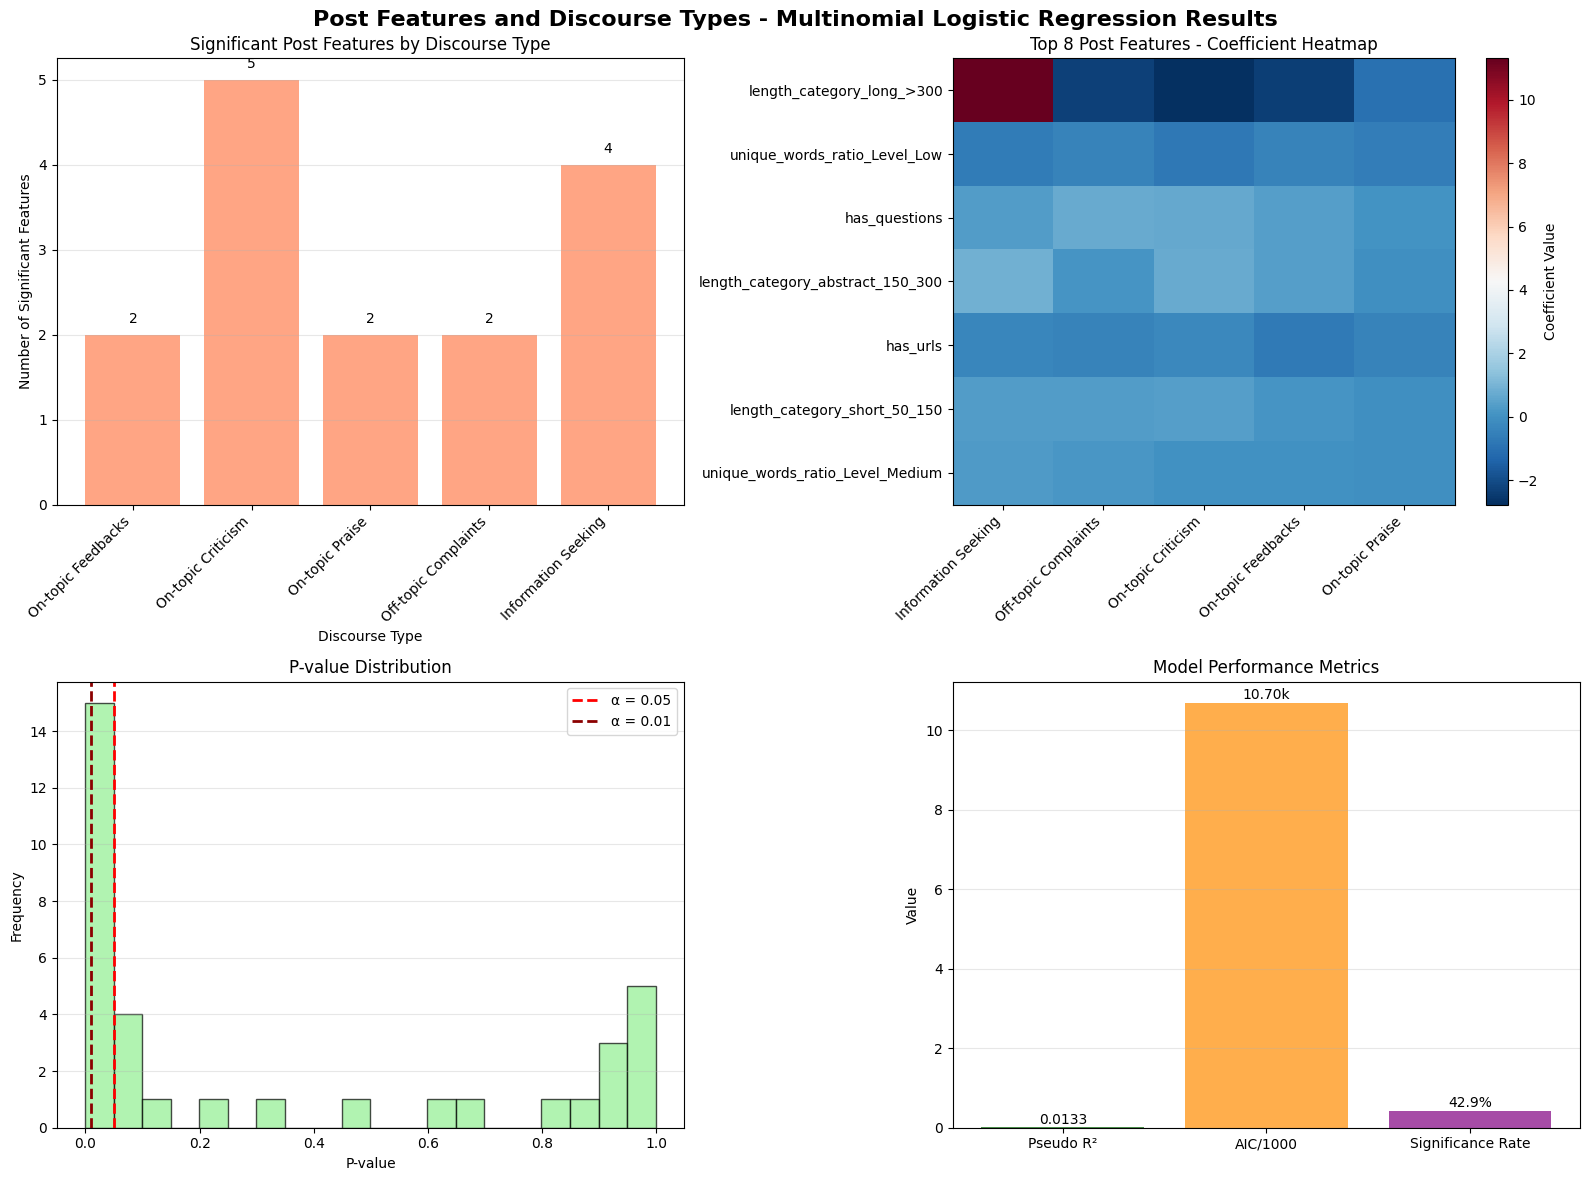

✅ Visualizations generated successfully!


In [47]:
# Visualization of Results
print("📊 VISUALIZATION OF POST FEATURES RESULTS")
print("=" * 39)

if 'results_df' in locals():
    
    # Create visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Post Features and Discourse Types - Multinomial Logistic Regression Results', 
                 fontsize=16, fontweight='bold')
    
    # 1. Significant features by discourse type
    ax1 = axes[0, 0]
    discourse_types = list(significant_by_discourse_type.keys())
    sig_counts = list(significant_by_discourse_type.values())
    
    bars1 = ax1.bar(range(len(discourse_types)), sig_counts, color='coral', alpha=0.7)
    ax1.set_title('Significant Post Features by Discourse Type')
    ax1.set_xlabel('Discourse Type')
    ax1.set_ylabel('Number of Significant Features')
    ax1.set_xticks(range(len(discourse_types)))
    ax1.set_xticklabels([dt.split(' (#')[0] for dt in discourse_types], rotation=45, ha='right')
    ax1.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, bar in enumerate(bars1):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{int(height)}', ha='center', va='bottom')
    
    # 2. Feature importance heatmap
    ax2 = axes[0, 1]
    
    # Create coefficient matrix for heatmap
    coeff_matrix = results_df.pivot(index='Feature', columns='Discourse_Comparison', values='Coefficient')
    
    # Plot heatmap with top 8 features
    top_features = feature_importance.head(8).index
    coeff_subset = coeff_matrix.loc[top_features]
    
    im = ax2.imshow(coeff_subset.values, cmap='RdBu_r', aspect='auto')
    ax2.set_title('Top 8 Post Features - Coefficient Heatmap')
    ax2.set_xticks(range(len(coeff_subset.columns)))
    ax2.set_xticklabels([col.split('_vs_')[0] for col in coeff_subset.columns], 
                       rotation=45, ha='right')
    ax2.set_yticks(range(len(top_features)))
    ax2.set_yticklabels(top_features, fontsize=10)
    
    # Add colorbar
    plt.colorbar(im, ax=ax2, label='Coefficient Value')
    
    # 3. P-value distribution (if available)
    ax3 = axes[1, 0]
    
    if has_pvalues:
        pvals = results_df['P_value'].dropna()
        ax3.hist(pvals, bins=20, alpha=0.7, color='lightgreen', edgecolor='black')
        ax3.axvline(0.05, color='red', linestyle='--', linewidth=2, label='α = 0.05')
        ax3.axvline(0.01, color='darkred', linestyle='--', linewidth=2, label='α = 0.01')
        ax3.set_title('P-value Distribution')
        ax3.set_xlabel('P-value')
        ax3.set_ylabel('Frequency')
        ax3.legend()
        ax3.grid(axis='y', alpha=0.3)
    else:
        ax3.text(0.5, 0.5, 'P-values not available', 
                transform=ax3.transAxes, ha='center', va='center', fontsize=14)
        ax3.set_title('P-value Distribution')
    
    # 4. Model performance summary
    ax4 = axes[1, 1]
    
    # Performance metrics
    metrics = {
        'Pseudo R²': results.prsquared,
        'AIC/1000': results.aic / 1000,  # Scale for visibility
        'Significance Rate': significance_rate / 100  # Convert to proportion
    }
    
    metric_names = list(metrics.keys())
    metric_values = list(metrics.values())
    
    bars4 = ax4.bar(metric_names, metric_values, 
                   color=['darkgreen', 'darkorange', 'purple'], alpha=0.7)
    ax4.set_title('Model Performance Metrics')
    ax4.set_ylabel('Value')
    ax4.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for i, bar in enumerate(bars4):
        height = bar.get_height()
        if metric_names[i] == 'AIC/1000':
            label = f'{height:.2f}k'
        elif metric_names[i] == 'Significance Rate':
            label = f'{height*100:.1f}%'
        else:
            label = f'{height:.4f}'
        
        ax4.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                label, ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Visualizations generated successfully!")
    
else:
    print("❌ No data available for visualization")

In [48]:
# Export Results
print("💾 EXPORT POST FEATURES RESULTS")
print("=" * 30)

if 'results_df' in locals():
    
    # Export detailed results to CSV
    output_path = r"C:\Users\20245179\OneDrive - TU Eindhoven\Research Paper\Analysis_pipeline\Post_Features_Discourse_Types_Results.csv"
    results_df.to_csv(output_path, index=False)
    print(f"✅ Detailed results exported to: {output_path}")
    
    # Create summary report
    summary_path = r"C:\Users\20245179\OneDrive - TU Eindhoven\Research Paper\Analysis_pipeline\Post_Features_Model_Summary.txt"
    
    with open(summary_path, 'w') as f:
        f.write("POST FEATURES AND DISCOURSE TYPES - MULTINOMIAL LOGISTIC REGRESSION SUMMARY\n")
        f.write("=" * 80 + "\n\n")
        
        f.write(f"Model Performance:\n")
        f.write(f"- Pseudo R-squared: {results.prsquared:.4f}\n")
        f.write(f"- AIC: {results.aic:.4f}\n")
        f.write(f"- Log-Likelihood: {results.llf:.4f}\n")
        f.write(f"- Number of observations: {int(results.nobs)}\n\n")
        
        f.write(f"Statistical Significance:\n")
        f.write(f"- Total relationships: {total_relationships}\n")
        f.write(f"- Significant relationships: {significant_relationships}\n")
        f.write(f"- Significance rate: {significance_rate:.1f}%\n\n")
        
        f.write(f"Significant Post Features by Discourse Type:\n")
        for discourse_type, count in significant_by_discourse_type.items():
            f.write(f"- {discourse_type}: {count} significant features\n")
        
        f.write(f"\nTop 5 Most Important Post Features:\n")
        for i, (feature, importance) in enumerate(feature_importance.head(5).items(), 1):
            f.write(f"{i}. {feature}: {importance:.4f}\n")
    
    print(f"✅ Model summary exported to: {summary_path}")
    
    # Display final summary
    print(f"\n📋 FINAL SUMMARY")
    print("-" * 15)
    print(f"📊 Analysis completed for {len(post_feature_columns)} post characteristics features")
    print(f"🎯 Model explains {results.prsquared*100:.2f}% of variance in discourse type assignment")
    print(f"📈 Found {significant_relationships} significant relationships out of {total_relationships}")
    print(f"💾 Results saved to CSV and summary files")
    
else:
    print("❌ No results to export")

print(f"\n🎉 POST FEATURES ANALYSIS COMPLETE!")

💾 EXPORT POST FEATURES RESULTS
✅ Detailed results exported to: C:\Users\20245179\OneDrive - TU Eindhoven\Research Paper\Analysis_pipeline\Post_Features_Discourse_Types_Results.csv
✅ Model summary exported to: C:\Users\20245179\OneDrive - TU Eindhoven\Research Paper\Analysis_pipeline\Post_Features_Model_Summary.txt

📋 FINAL SUMMARY
---------------
📊 Analysis completed for 4 post characteristics features
🎯 Model explains 1.33% of variance in discourse type assignment
📈 Found 15 significant relationships out of 35
💾 Results saved to CSV and summary files

🎉 POST FEATURES ANALYSIS COMPLETE!
